In [1]:
import os
import sys
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))
# os.environ["PYTHONPATH"] = '/opt/venv/lib/python3.11/site-packages'

import gc
import logging
import multiprocessing
import pickle
import time
import datetime
from functools import partial
from pathlib import Path
from typing import Any, Literal, Union

import dgl
import numpy as np
import pandas as pd
import pysmiles
import torch
from datasets import Dataset, IterableDataset, disable_caching, load_dataset, load_from_disk
from dgl.dataloading import GraphDataLoader
from dgl.heterograph import DGLGraph

from rdkit import Chem
from tqdm.auto import tqdm
import lancedb
import pyarrow as pa

try:
    import torch
except ImportError:
    torch = None

from molr.data_processing import mol_to_dgl, networkx_to_dgl
from molr.model import GNN
from molr.interface import MolRSmilesEmbedder
logging.getLogger('pysmiles').setLevel(logging.CRITICAL)

from multiprocess import set_start_method
try:
    set_start_method("spawn")
except RuntimeError as e:
    print(e)

disable_caching()  # disables caching for datasets

/home/r.schutski/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_PATH = Path('../saved/tag_1024')
DATA_PATH = Path("../../data/CS2/train.csv")

embedder = MolRSmilesEmbedder(MODEL_PATH)
dataset = load_dataset('csv', data_files=str(DATA_PATH), split='train')

In [3]:
emb_dataset_head = dataset.select(range(1)).map(embedder.process_hf_dataset, batched=False, batch_size=128)
# emb_dataset = dataset.map(embedder.process_hf_dataset, batched=True, batch_size=128)

Map: 100%|██████████| 1/1 [00:00<00:00, 22.56 examples/s]


In [67]:
emb_dataset = load_from_disk(str(DATA_PATH.parent / 'all_embeddings'))
dimension = len(emb_dataset[0]['vector'])
print(f"embedding dimension: {dimension}")

embedding dimension: 1024


In [4]:
uri = "../data/lancedb_demo"
db = lancedb.connect(uri)


In [5]:
def create_schema_from_dataset(
    dataset: Dataset, dimension: int, only_fields: Union[list[str], None] = None):
    schema = dataset.features.arrow_schema.remove_metadata()

    # replace the vector field if it already exists with a fixed size list
    idx = schema.get_field_index("vector")
    if idx != -1:
        schema = schema.remove(schema.get_field_index("vector"))
    schema = schema.insert(0, pa.field("vector", pa.list_(pa.float32(), list_size=dimension)))

    # remove all fields that are not in the only_fields list
    all_fields = dataset.features.keys()
    if only_fields is not None:
        for field in all_fields:
            if field not in only_fields:
                schema = schema.remove(schema.get_field_index(field))
    return schema


In [7]:
if 'chembl' in db.table_names():
    tbl = db.open_table("chembl")

In [8]:
schema = create_schema_from_dataset(emb_dataset_head, dimension=1024)
db.drop_table("chembl", ignore_missing=True)
tbl = db.create_table("chembl", schema=schema)

In [ ]:
start = time.time()
tbl.add(emb_dataset)
end = time.time()
import_time = end - start
print(f"Time to import data into db: {import_time // 60:.2f} min {import_time % 60:.2f} seconds")

In [ ]:
if torch is not None and torch.cuda.is_available():
    accelerator = 'cuda'
else:
    accelerator = None
start = time.time()
tbl.create_index(
    num_partitions=int(np.sqrt(len(emb_dataset))),  # number of centroids
    num_sub_vectors=64,                             # divisor of the vector dimension
    accelerator=accelerator   # build kNN index on GPU
)
end = time.time()
indexing_time = end - start
print(f"Indexing time: {indexing_time // 60:.2f} min {indexing_time:.2f} seconds")

In [41]:
def extract_centroids(dataset, index_name=None):
    if index_name is None:
        for idx in dataset.list_indices():
            if idx['type'] in ['IVF', 'IVF_PQ']:
                index_name = idx['name']
                break
    if index_name is None:
        raise ValueError('No IVF indices found')
    index_stats = dataset.index_statistics(index_name)
    if index_stats['num_indices'] > 1:
        raise ValueError(f"Only one index is supported, got {index_stats['num_indices']}")
    index = index_stats['indices'][0]
    # PQ index specific
    centroids = [pa.array(c, pa.float32()).to_numpy() for c in index['centroids']]
    partitions = pa.array([p['size'] for p in index['partitions']], pa.int32())
    return np.array(centroids), partitions.to_numpy()

In [45]:
centroids, partitions = extract_centroids(tbl._dataset)
centroids.shape

(1013, 1024)

In [59]:
db.drop_table("centroids", ignore_missing=True)
data = pa.Table.from_arrays(
    [
        pa.FixedSizeListArray.from_arrays(
            pa.array(centroids.flatten(), pa.float32()), centroids.shape[1]
        ),
        pa.array(range(len(centroids))),
    ],
    ['vector', 'cluster_id'],
)
tbl_centr = db.create_table(
    "centroids", data=data)

In [64]:
tbl_centr.create_scalar_index("cluster_id", replace=True)
tbl_centr.create_index(
    num_partitions=int(np.sqrt(len(centroids))),    # number of centroids
    num_sub_vectors=1,                              # divisor of the vector dimension
    accelerator=accelerator                              # build kNN index on GPU
)
tbl_centr.search(centroids[0]).where("cluster_id > 10", prefilter=True).to_pandas()

,vector,cluster_id,_distance
0,"[-2.4973383, 1.236109, 0.95818305, 1.0045329, ...",302,450.850800
1,"[-2.7758927, 2.0927045, 0.56550217, 1.3080217,...",290,450.850800
2,"[-3.1309464, 1.4423224, 0.92857575, 0.06649616...",799,630.038025
3,"[-2.5519977, 0.52025443, 0.58135647, 0.9162607...",255,878.604858
4,"[-3.5368097, 0.61234814, 0.67341584, 2.031657,...",485,878.604858
5,"[-2.002554, 1.7677107, 0.44458756, 1.7419734, ...",211,887.714417
6,"[-1.8009895, 0.78642625, 0.05130596, 1.5864938...",66,888.442749
7,"[-2.5409815, 2.0118918, 1.1566312, -0.15914823...",554,1035.491821
8,"[-3.9598122, 2.118699, 1.479663, 0.12578942, -...",810,1035.491821
9,"[-1.8606021, 0.9770243, 0.33754227, 0.63386554...",569,1114.057251


In [65]:
def test_search_speed(table, dataset, batch_sizes=[16, 32, 64, 128], num_retries=5):
    times = []
    accuracies_top1 = []
    accuracies_top5 = []
    for batch_size in tqdm(batch_sizes, leave=False, desc='batch_size', position=0):
        times_per_run = []
        accuracies_top1_per_run = []
        accuracies_top5_per_run = []
        for _ in range(num_retries):
            random_indices = np.random.randint(0, len(dataset) - 1, batch_size)
            random_smiles = [dd for dd in dataset.select(random_indices)['smiles']]
            data = [vec for vec in dataset.select(random_indices)['vector']]
            start = time.time()
            res = [table.search(vec).limit(5).select(["smiles", "main_reward"]).to_list() for vec in data]
            end = time.time()
            times_per_run.append(end - start)
            retrieved_smiles_top1 = [per_query[0]['smiles'] for per_query in res]
            retrieved_smiles_top5 = [dd['smiles'] for per_query in res for dd in per_query]
            accuracies_top1_per_run.append(len(set(retrieved_smiles_top1).intersection(set(random_smiles))) / batch_size)
            accuracies_top5_per_run.append(len(set(retrieved_smiles_top5).intersection(set(random_smiles))) / batch_size)
        times.append(np.mean(times_per_run))
        accuracies_top1.append(np.mean(accuracies_top1_per_run))
        accuracies_top5.append(np.mean(accuracies_top5_per_run))
    result = pd.DataFrame({'batch_size': batch_sizes, 'time': times, 'accuracy_top1': accuracies_top1, 'accuracy_top5': accuracies_top5})
    result['time_per_mol'] = result['time'] / result['batch_size']
    return result

In [68]:
results = test_search_speed(tbl, emb_dataset, batch_sizes=[16, 32, 64, 128], num_retries=5)

<AxesSubplot: title={'center': 'Search time per molecule'}, xlabel='batch size', ylabel='time (s)'>

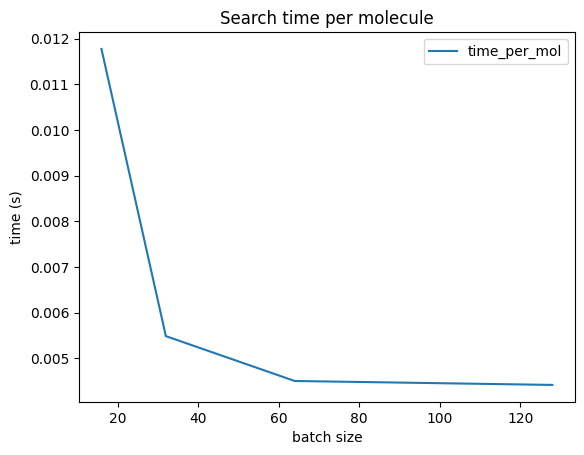

In [69]:
results.plot(x='batch_size', y='time_per_mol', title='Search time per molecule', ylabel='time (s)', xlabel='batch size')

<AxesSubplot: title={'center': 'Top 1 recall'}, xlabel='batch size', ylabel='recall'>

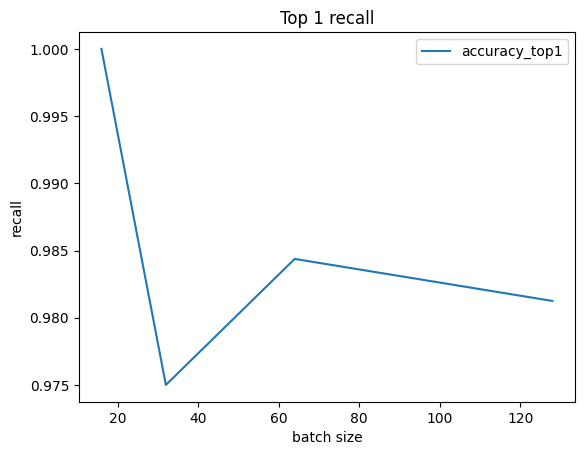

In [70]:
results.plot(x='batch_size', y='accuracy_top1', title='Top 1 recall', ylabel='recall', xlabel='batch size')